# **CÀI ĐẶT THƯ VIỆN**

In [1]:
!pip install underthesea
!pip install wordcloud
!pip install transformers
!pip install datasets
!pip install accelerate
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.1 MB/s eta 0:00:00


# **IMPORT THƯ VIỆN**

In [2]:
import pandas as pd
import numpy as np
import re
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from underthesea import word_tokenize

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# **TẢI DATASET**

In [3]:
from google.colab import files
import io

print("Chọn file để upload:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]


Chọn file để upload:


Saving data_augmented.csv to data_augmented.csv


# **ĐỌC DỮ LIỆU**

In [4]:
df = pd.read_csv(io.BytesIO(uploaded[filename]))

df = df[["text_clean", "intent"]].rename(columns={"text_clean": "text"})
df = df.dropna(subset=["text", "intent"]).reset_index(drop=True)

print(f"Tổng dòng: {len(df)}")
print(f"Các cột  : {df.columns.tolist()}")
df.head()


Tổng dòng: 8810
Các cột  : ['text', 'intent']


,text,intent
0,lần thứ mua ở shop nên chất_lượng khỏi bàn,khen_chat_luong
1,quan_trọng nhất là shop phục_vụ cực_kì tốt,khen_chat_luong
2,lần này đặt còn được tặng mã giảm_giá nữa,gia_tri_gia
3,ncl mình re com men de d mọi người nên mua nha,de_xuat_mua
4,than k shop ạ iu iu,trung_tinh


# **2. THÔNG TIN TỔNG QUAN**

**2.1. THÔNG TIN DATASET**

In [5]:
print("Các intent trong dataset:")
print(df["intent"].value_counts())


Các intent trong dataset:
intent
khen_chat_luong        1853
trung_tinh             1715
de_xuat_mua             903
phan_nan_giao_hang      885
khen_dich_vu            809
phan_nan_dich_vu        762
gia_tri_gia             755
dung_voi_mo_ta          394
khen_giao_hang          367
phan_nan_chat_luong     367
Name: count, dtype: int64


In [6]:
print("Số dòng:", len(df))
print("Số cột:", len(df.columns))

print("\nCác intent:")
print(df.intent.unique())

Số dòng: 8810
Số cột: 2

Các intent:
['khen_chat_luong' 'gia_tri_gia' 'de_xuat_mua' 'trung_tinh' 'khen_dich_vu'
 'khen_giao_hang' 'dung_voi_mo_ta' 'phan_nan_chat_luong'
 'phan_nan_giao_hang' 'phan_nan_dich_vu']


**2.2. GIÁ TRỊ THIẾU (NULL)**

In [7]:
df.isnull().sum()

,0
text,0
intent,0


**2.3. PHÂN BỐ INTENT**

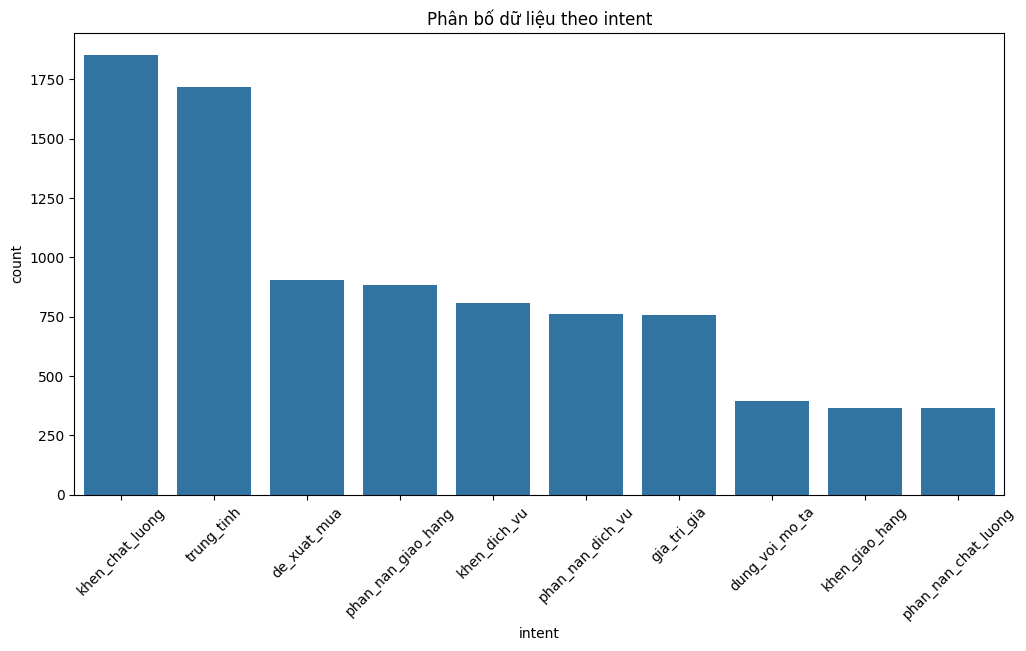

In [8]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="intent",
    order=df.intent.value_counts().index
)

plt.title("Phân bố dữ liệu theo intent")

plt.xticks(rotation=45)

plt.show()

**2.4. ĐỘ DÀI CÂU CHAT**

In [9]:
df["length"] = df["text"].apply(len)

df["length"].describe()

,length
count,8810.000000
mean,42.214188
std,32.724301
min,3.000000
25%,20.000000
50%,32.000000
75%,53.000000
max,316.000000


**2.5. HISTOGRAM**

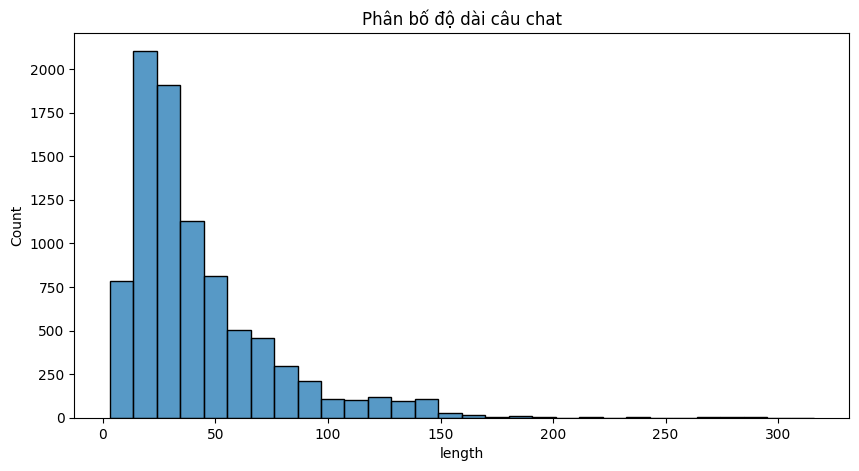

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["length"],
    bins=30
)

plt.title("Phân bố độ dài câu chat")

plt.show()

**2.6. WORD CLOUD**

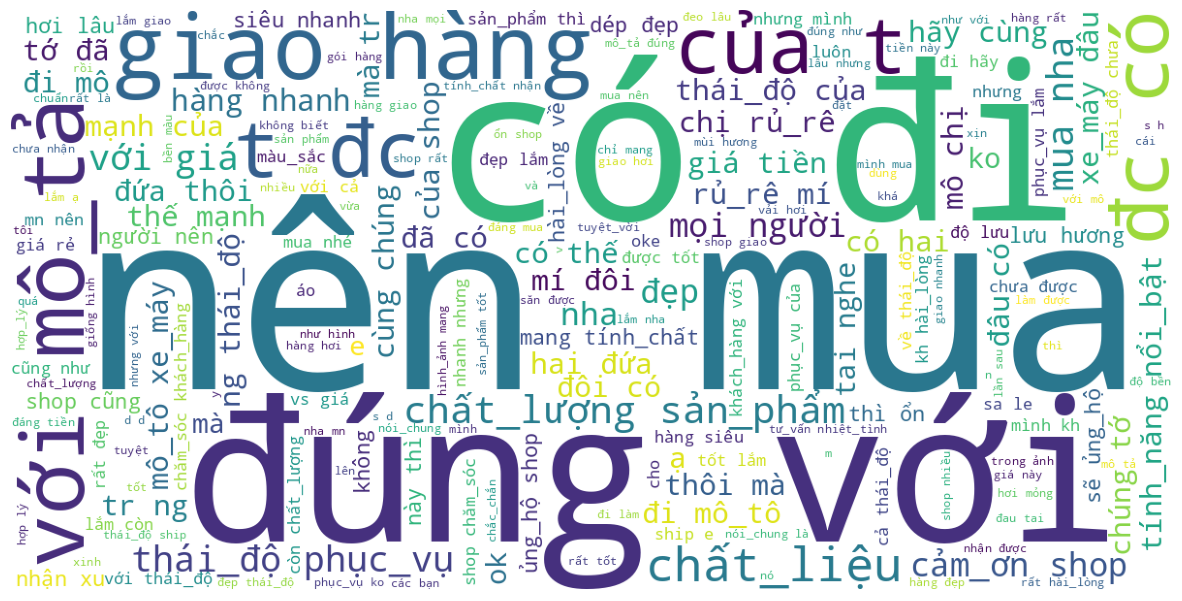

In [11]:
text = " ".join(df["text"])

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
)

wc.generate(text)

plt.figure(figsize=(15,8))
plt.imshow(wc)
plt.axis("off")
plt.show()

**2.7. WORD CLOUD THEO TỪNG INTENT**

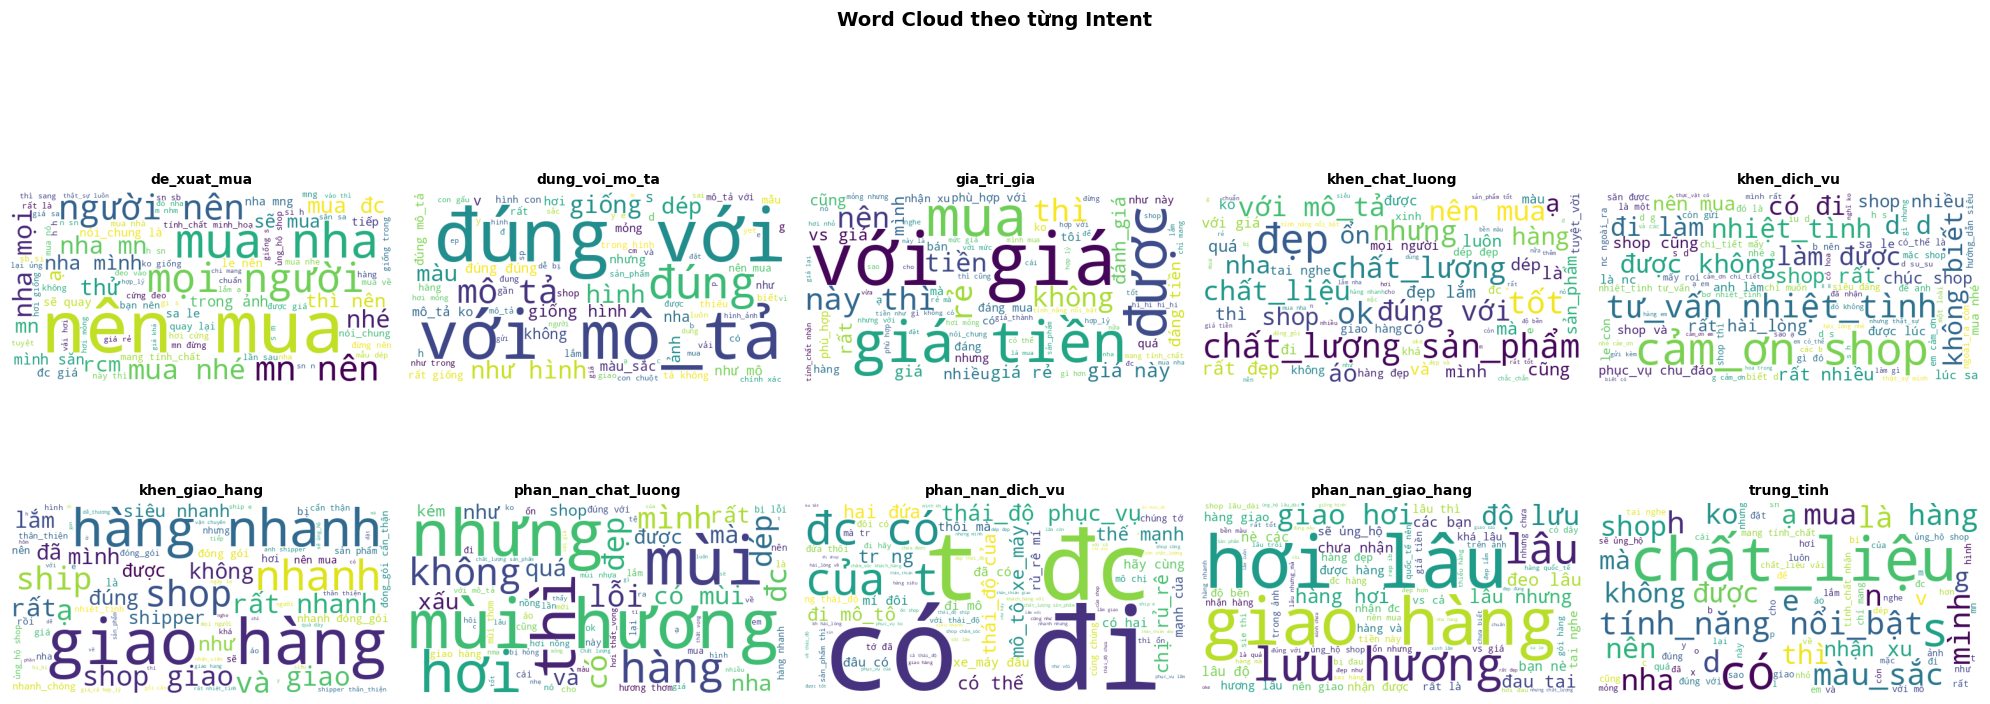

In [12]:
intents = df["intent"].unique()
n = len(intents)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, intent in enumerate(sorted(intents)):
    subset = df[df["intent"] == intent]["text"]
    text   = " ".join(subset.dropna())
    wc_intent = WordCloud(
        width=600, height=300,
        background_color="white",
        max_words=80
    ).generate(text)
    axes[i].imshow(wc_intent)
    axes[i].axis("off")
    axes[i].set_title(intent, fontsize=10, fontweight="bold")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Word Cloud theo từng Intent", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# **3. TIỀN XỬ LÝ**



**3.1. LabelEncoder**

In [13]:
import re
from underthesea import word_tokenize

def clean_text(text):
    text = str(text).lower() # Chuyển về chữ thường
    text = re.sub(r'[.,!?;:\\]', '', text) # Loại bỏ dấu câu
    text = re.sub(r'\d+', '', text) # Loại bỏ số
    text = word_tokenize(text, format='text') # Tokenize sử dụng underthesea
    return text

df["clean_text"] = df["text"].apply(clean_text)

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["label"] = encoder.fit_transform(df["intent"])

print("Mẫu sau tiền xử lý:")
df[["text", "clean_text", "intent", "label"]].head()

Mẫu sau tiền xử lý:


,text,clean_text,intent,label
0,lần thứ mua ở shop nên chất_lượng khỏi bàn,lần thứ mua ở shop nên chất_lượng khỏi bàn,khen_chat_luong,3
1,quan_trọng nhất là shop phục_vụ cực_kì tốt,quan_trọng nhất là shop phục_vụ cực_kì tốt,khen_chat_luong,3
2,lần này đặt còn được tặng mã giảm_giá nữa,lần này đặt còn được tặng mã_giảm_giá nữa,gia_tri_gia,2
3,ncl mình re com men de d mọi người nên mua nha,ncl mình re com men de_d mọi người nên mua nha,de_xuat_mua,0
4,than k shop ạ iu iu,than k shop ạ iu iu,trung_tinh,9


**3.2. TRAIN TEST SPLIT**

In [14]:
X = df["clean_text"]
y = df["label"]
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

**3.3. TF-IDF**

In [15]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f"TF-IDF matrix: {X_train_tfidf.shape}")


TF-IDF matrix: (7048, 5000)


**3.4. HUẤN LUYỆN NAIVE BAYES**

In [16]:
nb = MultinomialNB()
nb.fit(
    X_train_tfidf,
    y_train
)
nb_pred = nb.predict(
    X_test_tfidf
)

**3.5. HUẤN LUYỆN LOGISTIC**

In [17]:
lr = LogisticRegression(
    max_iter=1000
)
lr.fit(
    X_train_tfidf,
    y_train
)
lr_pred = lr.predict(
    X_test_tfidf
)

**3.6. HUẤN LUYỆN SVM**

In [18]:
svm = LinearSVC()
svm.fit(
    X_train_tfidf,
    y_train
)
svm_pred = svm.predict(
    X_test_tfidf
)

**3.7. CROSS-VALIDATION (5-FOLD)**

In [19]:
from sklearn.model_selection import cross_val_score
import numpy as np

for name, clf in [("Naive Bayes", MultinomialNB()),
                  ("Logistic Regression", LogisticRegression(max_iter=1000)),
                  ("SVM", LinearSVC())]:
    scores = cross_val_score(clf, X_train_tfidf, y_train, cv=5, scoring="f1_weighted")
    print(f"{name:22s}: F1 = {scores.mean():.4f} ± {scores.std():.4f}")


Naive Bayes           : F1 = 0.8235 ± 0.0071
Logistic Regression   : F1 = 0.8891 ± 0.0049
SVM                   : F1 = 0.9241 ± 0.0033


**3.8. HÀM ĐÁNH GIÁ**

In [20]:
def evaluate(name,y_true,y_pred):
    return {
        "Model":name,
        "Accuracy":
        accuracy_score(y_true,y_pred),
        "Precision":
        precision_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "Recall":
        recall_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "F1":
        f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    }

**3.9. BẢNG KẾT QUẢ**

In [21]:
results = []
results.append(
    evaluate(
        "Naive Bayes",
        y_test,
        nb_pred
    )
)
results.append(
    evaluate(
        "Logistic Regression",
        y_test,
        lr_pred
    )
)
results.append(
    evaluate(
        "SVM",
        y_test,
        svm_pred
    )
)

result_df = pd.DataFrame(results)

result_df

,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.847900,0.864020,0.847900,0.842530
1,Logistic Regression,0.910329,0.914103,0.910329,0.909611
2,SVM,0.931896,0.933048,0.931896,0.931692


**3.10. BIỂU ĐỒ SO SÁNH**

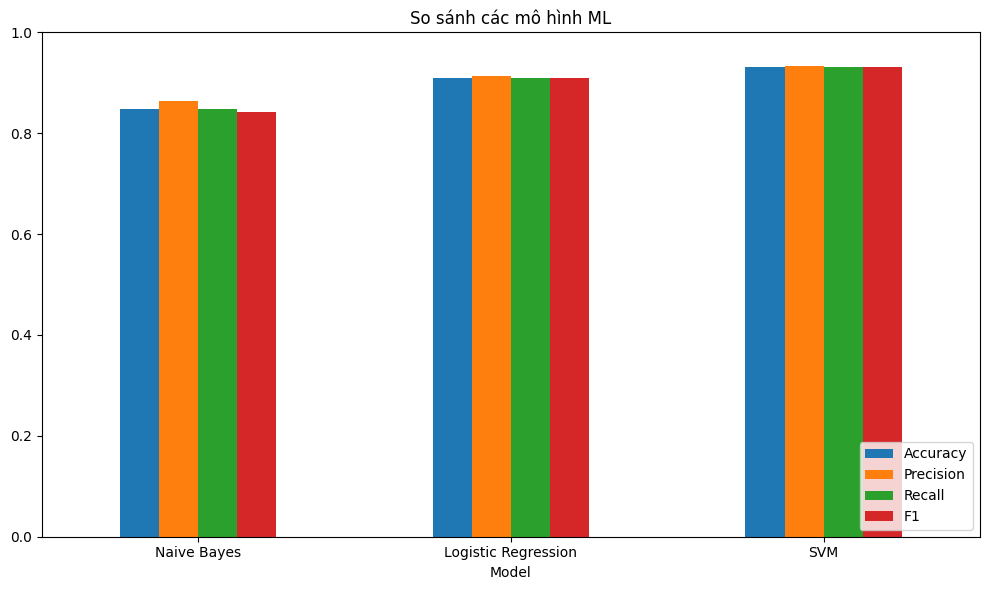

In [22]:
result_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1"],
    kind="bar",
    figsize=(10, 6)
)
plt.title("So sánh các mô hình ML")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


**3.11. CONFUSION MATRIX**

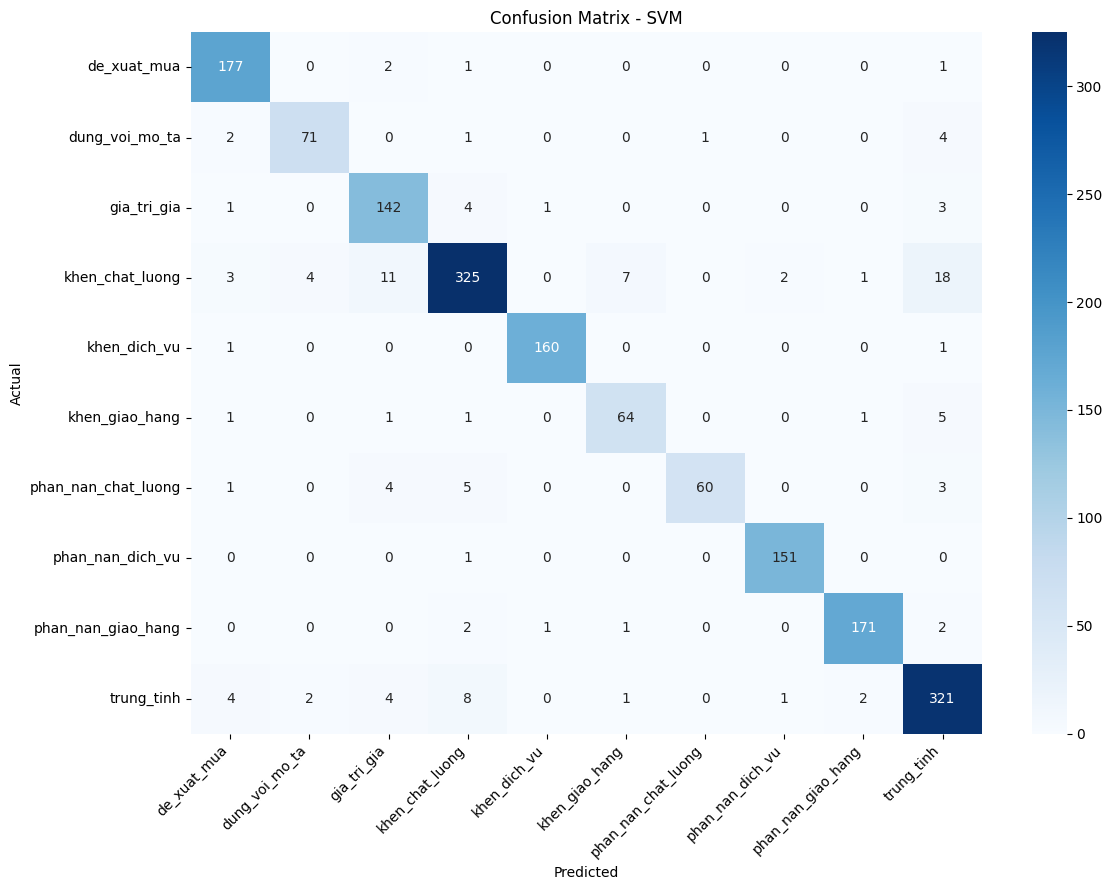

In [23]:
cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**3.12. CLASSIFICATION REPORT**

In [24]:
print(classification_report(
    y_test,
    svm_pred,
    target_names=encoder.classes_
))


                     precision    recall  f1-score   support

        de_xuat_mua       0.93      0.98      0.95       181
     dung_voi_mo_ta       0.92      0.90      0.91        79
        gia_tri_gia       0.87      0.94      0.90       151
    khen_chat_luong       0.93      0.88      0.90       371
       khen_dich_vu       0.99      0.99      0.99       162
     khen_giao_hang       0.88      0.88      0.88        73
phan_nan_chat_luong       0.98      0.82      0.90        73
   phan_nan_dich_vu       0.98      0.99      0.99       152
 phan_nan_giao_hang       0.98      0.97      0.97       177
         trung_tinh       0.90      0.94      0.92       343

           accuracy                           0.93      1762
          macro avg       0.94      0.93      0.93      1762
       weighted avg       0.93      0.93      0.93      1762



# **4. PHOBERT**

**4.1. CÀI ĐẶT PHOBERT**

In [25]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

**4.2. CHUẨN BỊ DỮ LIỆU CHO PHOBERT**

In [26]:
num_labels = len(encoder.classes_)
print("Số lớp:", num_labels)
print("Thứ tự nhãn:", list(encoder.classes_))


Số lớp: 10
Thứ tự nhãn: ['de_xuat_mua', 'dung_voi_mo_ta', 'gia_tri_gia', 'khen_chat_luong', 'khen_dich_vu', 'khen_giao_hang', 'phan_nan_chat_luong', 'phan_nan_dich_vu', 'phan_nan_giao_hang', 'trung_tinh']


**4.3. TRAIN TEST SPLIT**

In [27]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)
print(train_df.shape)
print(test_df.shape)

(7048, 5)
(1762, 5)


**4.4. LOAD TOKENIZER**

In [28]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(
    "vinai/phobert-base"
)

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

**4.5. TOKENIZE**

In [29]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )


**4.6. CHUYỂN SANG DATASET HUGGINGFACE**

In [30]:
from datasets import Dataset
train_dataset = Dataset.from_pandas(
    train_df[["text","label"]]
)
test_dataset = Dataset.from_pandas(
    test_df[["text","label"]]
)
train_dataset

Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 7048
})

**4.7. TOKENIZE DATASET**

In [31]:
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)
test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)
train_dataset.set_format(

    type="torch",

    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)
test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

Map:   0%|          | 0/7048 [00:00<?, ? examples/s]

Map:   0%|          | 0/1762 [00:00<?, ? examples/s]

**4.8. LOAD PHOBERT MODEL**

In [32]:
from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/phobert-base",
    num_labels=num_labels
)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**4.9. THIẾT LẬP TRAINING**

In [33]:
training_args = TrainingArguments(
    output_dir="./phobert_result",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2
)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


**4.10. METRICS**

In [34]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted"
    )
    acc = accuracy_score(
        labels,
        preds
    )
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

**4.11. TRAIN PHOBERT**

In [35]:
import torch
print('Torch version :', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

if not torch.cuda.is_available():
    print()
    print("CẢNH BÁO: Không phát hiện GPU!")
    print("PhoBERT sẽ train rất chậm trên CPU (~10x so với GPU).")
    print("→ Vào Runtime > Change runtime type > chọn T4 GPU rồi chạy lại từ đầu.")
else:
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Torch version : 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [36]:
import sys
print("torchvision" in sys.modules)

True


In [37]:
import sys
if "torchvision" in sys.modules:
    del sys.modules["torchvision"]
print("torchvision" in sys.modules)

False


In [38]:
from transformers import Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.668573,0.487169,0.870034,0.870500,0.870034,0.867764
2,0.298516,0.278131,0.926220,0.926447,0.926220,0.926071
3,0.128270,0.236411,0.943246,0.943913,0.943246,0.943222
4,0.090485,0.232390,0.950624,0.950991,0.950624,0.950529
5,0.076783,0.235712,0.950624,0.951692,0.950624,0.950674


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2205, training_loss=0.4459182924964801, metrics={'train_runtime': 780.0276, 'train_samples_per_second': 45.178, 'train_steps_per_second': 2.827, 'total_flos': 1159087448709120.0, 'train_loss': 0.4459182924964801, 'epoch': 5.0})

**4.12. KẾT QUẢ PHOBERT**

In [39]:
eval_result = trainer.evaluate()
print(eval_result)
eval_result


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.076783,0.235712,5,0.950624,0.951692,0.950624,0.950674


{'eval_loss': 0.23571167886257172, 'eval_accuracy': 0.9506242905788876, 'eval_precision': 0.951692489239745, 'eval_recall': 0.9506242905788876, 'eval_f1': 0.9506735217528838}


{'eval_loss': 0.23571167886257172,
 'eval_accuracy': 0.9506242905788876,
 'eval_precision': 0.951692489239745,
 'eval_recall': 0.9506242905788876,
 'eval_f1': 0.9506735217528838}

**4.13. DỰ ĐOÁN THỬ**

In [40]:
import torch
def predict_phobert(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=32
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    pred = torch.argmax(
        outputs.logits,
        dim=1
    )
    label = encoder.inverse_transform(
        [pred.item()]
    )[0]
    return label

In [41]:
while True:
    text = input("Bạn: ")
    if text.lower() in ["exit", "quit", "q"]:
        print("Bot: Tạm biệt!")
        break
    result = predict_phobert(text)
    print("Bot: ",result)
    print("-" * 50)

Bạn: hơi đắt
Bot:  gia_tri_gia
--------------------------------------------------
Bạn: q
Bot: Tạm biệt!


**4.14. SO SÁNH PHOBERT VỚI ML**

In [42]:
eval_result = trainer.evaluate()

result_df.loc[len(result_df)] = [
    "PhoBERT",
    eval_result["eval_accuracy"],
    eval_result["eval_precision"],
    eval_result["eval_recall"],
    eval_result["eval_f1"]
]
result_df


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.076783,0.235712,5,0.950624,0.951692,0.950624,0.950674


,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.847900,0.864020,0.847900,0.842530
1,Logistic Regression,0.910329,0.914103,0.910329,0.909611
2,SVM,0.931896,0.933048,0.931896,0.931692
3,PhoBERT,0.950624,0.951692,0.950624,0.950674


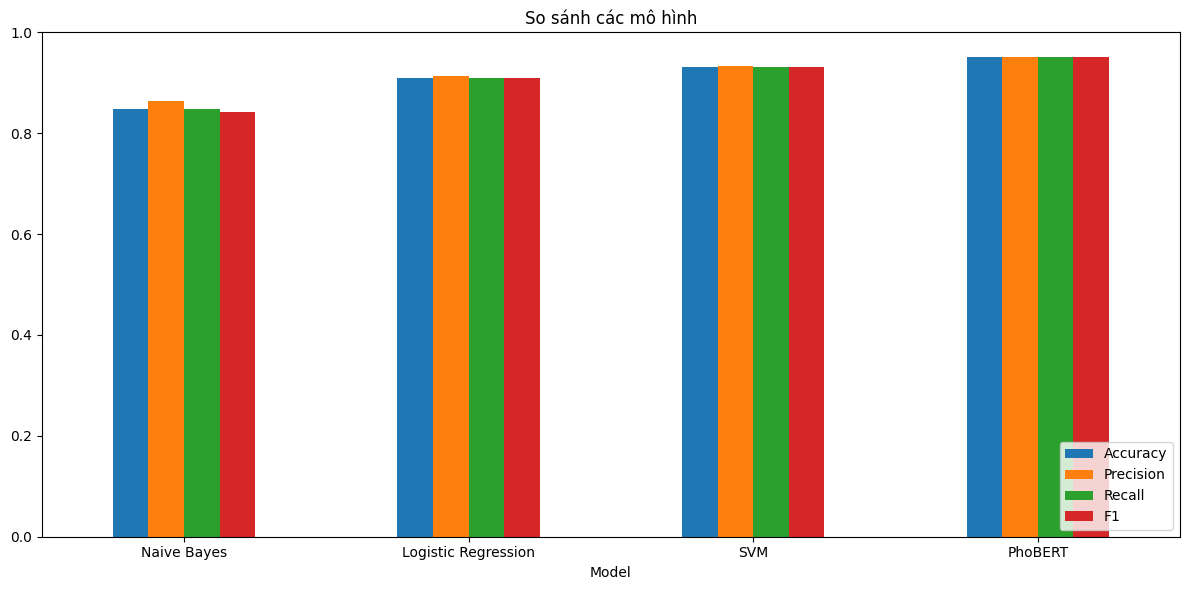

In [43]:
result_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1"],
    kind="bar",
    figsize=(12, 6)
)
plt.title("So sánh các mô hình")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
